# HW1 — Dự báo chuỗi thời gian bằng **ARIMA**, **LSTM** và **Hybrid ARIMA–LSTM**

**Nhóm thực hiện:** Ngân, Khoa, Nhân (UIT — Hệ thông tin)

## Bài toán

- Mỗi nhóm cài đặt **2 thuật toán** trong bài báo HW1 trên tập dữ liệu phù hợp với bài toán dự báo time series.
- Đề xuất cách **cải tiến / kết hợp** 2 thuật toán đó.

## Phương án nhóm chọn

| Thành phần | Lựa chọn | Vai trò |
|---|---|---|
| Thuật toán 1 (linear) | **ARIMA** | Bắt thành phần tuyến tính (trend + autocorrelation) |
| Thuật toán 2 (non-linear) | **LSTM** | Bắt pattern phi tuyến + memory dài hạn |
| Cải tiến / kết hợp | **Hybrid ARIMA–LSTM (Zhang 2003)** + **Weighted ensemble** | Hợp nhất ưu điểm 2 mô hình |
| Dataset | `sales_data.csv` (provided) | Dữ liệu bán hàng thực tế |

## Pipeline tổng quát

```
            ┌─────────────────────────────────────┐
 raw data → │ clean → resample → train/val/test   │
            └─────────────────────────────────────┘
                          │
        ┌─────────────────┼─────────────────┐
        ▼                 ▼                 ▼
     ARIMA(p,d,q)      LSTM           Hybrid:
     baseline          baseline       (1) ARIMA fit → linear ŷ_a
                                      (2) residuals = y - ŷ_a
                                      (3) LSTM học residuals → ε̂
                                      (4) ŷ_hybrid = ŷ_a + ε̂
                                      (5) ensemble = w·ŷ_a + (1-w)·ŷ_l
        ▼                 ▼                 ▼
   ┌─────────────── Evaluation (MAE / RMSE / sMAPE) ───────────────┐
   └───────────────────────────────────────────────────────────────┘
```




## 1. Import thư viện và setup

Cell dưới sẽ tự cài thư viện thiếu (TensorFlow, statsmodels, sklearn...) trước khi chạy. Nếu chạy lần đầu, đợi vài phút để cài TensorFlow.

In [22]:
import sys, subprocess, importlib

REQUIRED = ["numpy", "pandas", "matplotlib", "scikit-learn", "statsmodels", "tensorflow"]
IMPORT_NAMES = {"scikit-learn": "sklearn", "tensorflow": "tensorflow"}

missing = []
for pkg in REQUIRED:
    name = IMPORT_NAMES.get(pkg, pkg)
    if importlib.util.find_spec(name) is None:
        missing.append(pkg)

if missing:
    print("Đang cài:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + missing)

import warnings, os, math, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("TensorFlow version:", tf.__version__)
print("Setup OK")


TensorFlow version: 2.19.0
Setup OK


## 2. Helper functions — dùng chung cho pipeline

Toàn bộ code lõi (ARIMA grid search, LSTM, hybrid, evaluation) được đóng gói thành hàm để giữ pipeline gọn, dễ kiểm tra và tái sử dụng.


In [23]:
# ---------- Metrics ----------
def smape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    denom[denom == 0] = 1.0
    return 100.0 * np.mean(np.abs(y_true - y_pred) / denom)

def evaluate(y_true, y_pred, name="model"):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    return {
        "model": name,
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": math.sqrt(mean_squared_error(y_true, y_pred)),
        "sMAPE": smape(y_true, y_pred),
    }

# ---------- ARIMA grid search ----------
def choose_d(series, max_d=2):
    """Chọn bậc differencing nhỏ nhất để chuỗi dừng theo ADF."""
    s = series.dropna()
    for d in range(max_d + 1):
        test_series = s.diff(d).dropna() if d > 0 else s
        if len(test_series) < 10:
            continue
        pval = adfuller(test_series, autolag="AIC")[1]
        if pval < 0.05:
            return d
    return 1

def fit_arima(train, max_p=3, max_q=3):
    """Grid search ARIMA(p,d,q), trả về model fit có AIC thấp nhất."""
    d = choose_d(train)
    best = (None, np.inf, None)
    for p in range(max_p + 1):
        for q in range(max_q + 1):
            try:
                m = ARIMA(train, order=(p, d, q),
                          enforce_stationarity=False,
                          enforce_invertibility=False).fit()
                if m.aic < best[1]:
                    best = ((p, d, q), m.aic, m)
            except Exception:
                continue
    return best  # (order, aic, fitted_model)

# ---------- LSTM ----------
def make_supervised(series_values, look_back):
    """Convert 1D array thành supervised (X, y) với cửa sổ look_back."""
    X, y = [], []
    for i in range(len(series_values) - look_back):
        X.append(series_values[i : i + look_back])
        y.append(series_values[i + look_back])
    X = np.array(X).reshape(-1, look_back, 1)
    y = np.array(y).reshape(-1, 1)
    return X, y

def build_lstm(look_back, units=64, dropout=0.2):
    """LSTM 1 hidden layer 64 unit + dropout, output Dense(1)."""
    model = Sequential([
        Input(shape=(look_back, 1)),
        LSTM(units, return_sequences=False),
        Dropout(dropout),
        Dense(32, activation="relu"),
        Dense(1),
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

def lstm_forecast(train_values, test_len, look_back=12, epochs=200, verbose=0):
    """
    Train LSTM trên train_values (1D), forecast 'test_len' bước.
    Dùng recursive forecasting: feed dự báo trước vào cửa sổ tiếp theo.
    Trả về (predictions_1D, scaler, model, history).
    """
    train_values = np.asarray(train_values, float).reshape(-1, 1)
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(train_values).flatten()

    X, y = make_supervised(scaled, look_back)
    model = build_lstm(look_back)
    es = EarlyStopping(monitor="loss", patience=15, restore_best_weights=True)
    history = model.fit(X, y, epochs=epochs, batch_size=16,
                        verbose=verbose, callbacks=[es])

    # Recursive forecast
    window = list(scaled[-look_back:])
    preds_scaled = []
    for _ in range(test_len):
        x = np.array(window[-look_back:]).reshape(1, look_back, 1)
        yhat = model.predict(x, verbose=0).flatten()[0]
        preds_scaled.append(yhat)
        window.append(yhat)
    preds = scaler.inverse_transform(np.array(preds_scaled).reshape(-1, 1)).flatten()
    return preds, scaler, model, history

# ---------- Hybrid ARIMA-LSTM (Zhang 2003) ----------
def hybrid_arima_lstm(train, test, look_back=12, epochs=200, verbose=0):
    """
    Hybrid theo Zhang (2003):
      1) ARIMA fit trên train, lấy linear forecast trên test.
      2) Residuals = train - ARIMA.fittedvalues  (phần phi tuyến).
      3) LSTM học residuals, dự báo residuals trên test.
      4) Hybrid = ARIMA_forecast + LSTM_residual_forecast.
    """
    # Bước 1: ARIMA
    order, aic, arima_fit = fit_arima(train)
    arima_forecast = np.asarray(arima_fit.forecast(steps=len(test)))

    # Bước 2: residuals trên train
    fitted = np.asarray(arima_fit.fittedvalues)
    train_arr = np.asarray(train, float)
    # statsmodels có thể trả fittedvalues dài như train
    n = min(len(fitted), len(train_arr))
    residuals = train_arr[-n:] - fitted[-n:]

    # Bước 3: LSTM học residuals
    if len(residuals) > look_back + 5:
        resid_pred, _, _, _ = lstm_forecast(
            residuals, test_len=len(test),
            look_back=look_back, epochs=epochs, verbose=verbose,
        )
    else:
        # fallback: chuỗi quá ngắn, không học được residuals
        resid_pred = np.zeros(len(test))

    # Bước 4: cộng lại
    hybrid = arima_forecast + resid_pred
    return {
        "arima_order": order,
        "arima_aic": aic,
        "arima_forecast": arima_forecast,
        "residual_forecast": resid_pred,
        "hybrid_forecast": hybrid,
    }

# ---------- Weighted ensemble ----------
def weighted_ensemble(pred_a, pred_b, y_val_a, y_val_b, y_val_true):
    """
    Tìm w tối ưu cho ŷ = w * pred_a + (1-w) * pred_b
    bằng grid search theo MAE trên validation.
    """
    best_w, best_mae = 0.5, np.inf
    for w in np.linspace(0, 1, 21):
        cand = w * y_val_a + (1 - w) * y_val_b
        mae = mean_absolute_error(y_val_true, cand)
        if mae < best_mae:
            best_mae, best_w = mae, w
    final = best_w * pred_a + (1 - best_w) * pred_b
    return final, best_w, best_mae

# ---------- Plot helper ----------
def plot_predictions(train, test, preds_dict, title, ylabel):
    """preds_dict: {label: 1D-array predictions on test}."""
    plt.figure(figsize=(13, 5))
    plt.plot(train.index, train.values, label="Train", alpha=0.5, color="gray")
    plt.plot(test.index, test.values, label="Actual (Test)", linewidth=2.2, color="black")
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
    for i, (label, p) in enumerate(preds_dict.items()):
        plt.plot(test.index, p, label=label, linewidth=1.8, color=colors[i % len(colors)])
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()

print("Helper functions loaded.")


Helper functions loaded.


## 3. Dataset — `sales_data.csv`

Dữ liệu bán hàng (transaction-level). Pipeline:
1. Load CSV → tự nhận diện cột `Date` và cột target số (ưu tiên tên giống *units sold / sales / quantity / demand*).
2. Aggregate về **daily**: tổng đơn vị bán mỗi ngày.
3. Resample fill missing date → chuỗi liên tục.
4. Cap outlier theo IQR.
5. Chia train (70%) / val (15%) / test (15%) theo thứ tự thời gian.


In [24]:
# ---------- 3.1. Load ----------
DATA_PATH_CANDIDATES = [
    Path("sales_data.csv"),
    Path("/kaggle/input/datasets/nghanguynduytrng/sale-data-csv/sales_data.csv"),
   # Path("/Users/nhannguyen2-rainscales/Downloads/UIT/Hệ thông thông tin /sales_data.csv"),
]
sales_path = next((p for p in DATA_PATH_CANDIDATES if p.exists()), None)
assert sales_path is not None, "Không tìm thấy sales_data.csv — copy file vào cạnh notebook."

df_sales = pd.read_csv(sales_path)
print("Shape:", df_sales.shape)
df_sales.head()


Shape: (76000, 16)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.7200,5,Snowy,0,85.7300,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.1600,15,Snowy,1,92.0200,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.9400,10,Snowy,1,60.0800,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.6300,10,Snowy,0,85.1900,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.4100,0,Snowy,0,51.6300,Winter,0,59


In [25]:
# ---------- 3.2. Auto-detect date & target columns ----------
def detect_date_column(df):
    for c in df.columns:
        try:
            parsed = pd.to_datetime(df[c], errors="coerce")
            if parsed.notna().mean() > 0.8:
                return c
        except Exception:
            pass
    raise ValueError("Không tìm thấy cột thời gian.")

def detect_target(df, date_col):
    preferred = ["units sold", "unit sold", "sales", "demand", "quantity", "qty",
                 "revenue", "amount"]
    num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != date_col]
    # Ưu tiên cột có tên phù hợp
    for kw in preferred:
        for c in num_cols:
            if kw in c.lower():
                return c
    # Nếu không có, dùng cột số có variance lớn nhất
    return max(num_cols, key=lambda c: df[c].var())

date_col = detect_date_column(df_sales)
target_col = detect_target(df_sales, date_col)
print(f"Date column:   {date_col}")
print(f"Target column: {target_col}")


Date column:   Date
Target column: Units Sold


Period: 2022-01-01 → 2024-01-30
Length: 760 days
Mean:   8,882.73
Std:    1,558.66


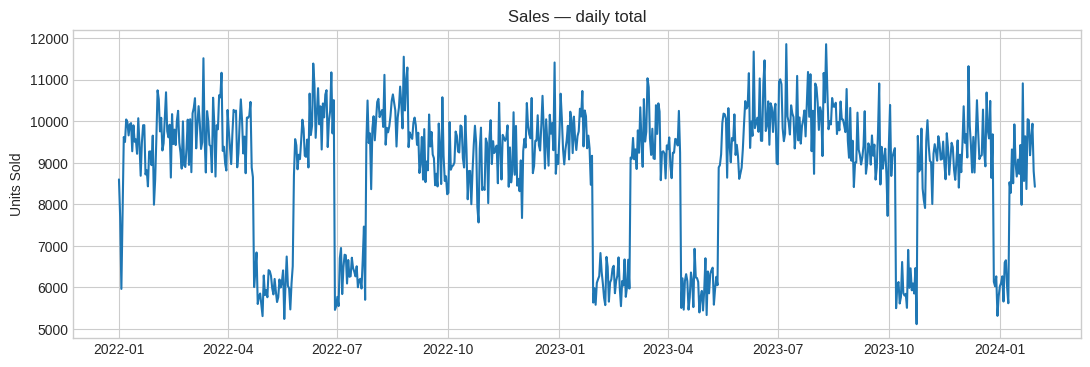

In [26]:
# ---------- 3.3. Aggregate to daily + clean ----------
df_sales[date_col] = pd.to_datetime(df_sales[date_col], errors="coerce")
df_sales = df_sales.dropna(subset=[date_col, target_col])

# Daily total
sales_daily = (df_sales.groupby(pd.Grouper(key=date_col, freq="D"))[target_col]
               .sum(min_count=1)
               .sort_index())

# Fill missing dates + interpolate
sales_daily = sales_daily.asfreq("D").interpolate(method="time").ffill().bfill()
sales_daily = sales_daily.clip(lower=0)

# Cap outlier IQR
q1, q3 = sales_daily.quantile([0.25, 0.75])
iqr = q3 - q1
sales_daily = sales_daily.clip(upper=q3 + 3 * iqr)

print(f"Period: {sales_daily.index.min().date()} → {sales_daily.index.max().date()}")
print(f"Length: {len(sales_daily)} days")
print(f"Mean:   {sales_daily.mean():,.2f}")
print(f"Std:    {sales_daily.std():,.2f}")

plt.figure(figsize=(13, 4))
plt.plot(sales_daily.index, sales_daily.values, color="tab:blue")
plt.title("Sales — daily total")
plt.ylabel(target_col)
plt.show()


In [27]:
# ---------- 3.4. Train / Val / Test split ----------
n = len(sales_daily)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)
sales_train = sales_daily.iloc[:n_train]
sales_val   = sales_daily.iloc[n_train : n_train + n_val]
sales_test  = sales_daily.iloc[n_train + n_val :]
print(f"Train: {len(sales_train)}  Val: {len(sales_val)}  Test: {len(sales_test)}")


Train: 532  Val: 114  Test: 114


### 3.5. Mô hình 1 — ARIMA (baseline)

In [28]:
order_s, aic_s, arima_s = fit_arima(sales_train, max_p=3, max_q=3)
print(f"Best ARIMA order: {order_s}   AIC={aic_s:.2f}")

arima_pred_s = np.asarray(arima_s.forecast(steps=len(sales_test)))
metrics_arima_s = evaluate(sales_test.values, arima_pred_s, "ARIMA")
pd.DataFrame([metrics_arima_s])


Best ARIMA order: (2, 0, 3)   AIC=8566.30


,model,MAE,RMSE,sMAPE
0,ARIMA,"1,309.8348","1,867.8403",16.0161


### 3.6. Mô hình 2 — LSTM (baseline)

LSTM 1 hidden layer 64 units, look-back = 14 ngày, scale [0,1] bằng MinMaxScaler. Recursive forecasting.

In [29]:
lstm_pred_s, scaler_s, model_s, hist_s = lstm_forecast(
    sales_train.values, test_len=len(sales_test),
    look_back=14, epochs=200, verbose=0,
)
metrics_lstm_s = evaluate(sales_test.values, lstm_pred_s, "LSTM")
pd.DataFrame([metrics_lstm_s])


,model,MAE,RMSE,sMAPE
0,LSTM,"1,266.3014","1,839.5422",15.5671


### 3.7. Cải tiến — Hybrid ARIMA–LSTM (Zhang 2003)

ARIMA dự báo linear, LSTM học **residuals** (phần phi tuyến mà ARIMA bỏ sót). Final = ARIMA + LSTM(residuals).

In [30]:
hybrid_s = hybrid_arima_lstm(sales_train, sales_test, look_back=14, epochs=200)
print(f"ARIMA order trong hybrid: {hybrid_s['arima_order']}  AIC={hybrid_s['arima_aic']:.2f}")

metrics_hybrid_s = evaluate(sales_test.values, hybrid_s["hybrid_forecast"], "Hybrid ARIMA-LSTM")
pd.DataFrame([metrics_hybrid_s])


ARIMA order trong hybrid: (2, 0, 3)  AIC=8566.30


,model,MAE,RMSE,sMAPE
0,Hybrid ARIMA-LSTM,"1,322.9576","1,837.9323",16.1950


### 3.8. Cải tiến phụ — Weighted Ensemble

Tinh chỉnh trọng số trên tập validation, sau đó áp lên test.

In [31]:
# Forecast trên validation bằng cả ARIMA và LSTM để tìm w*
val_len = len(sales_val)
arima_val = np.asarray(arima_s.forecast(steps=val_len + len(sales_test)))[:val_len]
lstm_val_pred, _, _, _ = lstm_forecast(
    sales_train.values, test_len=val_len, look_back=14, epochs=150, verbose=0,
)
ensemble_pred, w_star, val_mae = weighted_ensemble(
    arima_pred_s, lstm_pred_s, arima_val, lstm_val_pred, sales_val.values,
)
print(f"Weight tối ưu cho ARIMA: w* = {w_star:.2f}  (LSTM = {1-w_star:.2f})")
print(f"Validation MAE: {val_mae:.4f}")

metrics_ens_s = evaluate(sales_test.values, ensemble_pred, f"Weighted Ensemble (w={w_star:.2f})")
pd.DataFrame([metrics_ens_s])


Weight tối ưu cho ARIMA: w* = 1.00  (LSTM = 0.00)
Validation MAE: 961.6702


,model,MAE,RMSE,sMAPE
0,Weighted Ensemble (w=1.00),"1,309.8348","1,867.8403",16.0161


### 3.9. So sánh các mô hình trên test set


,model,MAE,RMSE,sMAPE
0,ARIMA,"1,309.8348","1,867.8403",16.0161
1,LSTM,"1,266.3014","1,839.5422",15.5671
2,Hybrid ARIMA-LSTM,"1,322.9576","1,837.9323",16.1950
3,Weighted Ensemble (w=1.00),"1,309.8348","1,867.8403",16.0161


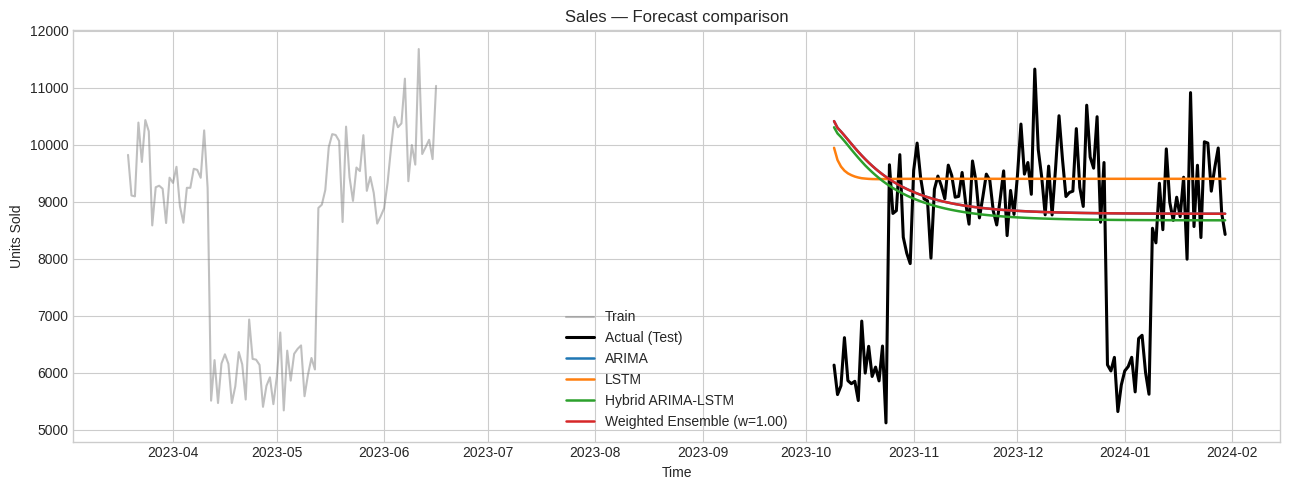

In [32]:
comparison_s = pd.DataFrame([metrics_arima_s, metrics_lstm_s, metrics_hybrid_s, metrics_ens_s])
display(comparison_s)

plot_predictions(
    sales_train.iloc[-90:], sales_test,
    {
        "ARIMA": arima_pred_s,
        "LSTM":  lstm_pred_s,
        "Hybrid ARIMA-LSTM": hybrid_s["hybrid_forecast"],
        f"Weighted Ensemble (w={w_star:.2f})": ensemble_pred,
    },
    title="Sales — Forecast comparison",
    ylabel=target_col,
)


## 4. Lưu kết quả ra CSV

In [33]:
from pathlib import Path

out_dir = Path("forecast_outputs"); out_dir.mkdir(exist_ok=True)
comparison_s.to_csv(out_dir / "sales_results.csv", index=False)
print(f"Đã lưu metric vào {out_dir/'sales_results.csv'}")


Đã lưu metric vào forecast_outputs/sales_results.csv
